The US Superstore Dataset contains the following attributes:

Row ID: Unique ID for each row.
Order ID: Unique Order ID for each Customer.
Order Date: Order Date of the product.
Ship Date: Shipping Date of the Product.
Ship Mode: Shipping Mode specified by the Customer.
Customer ID: Unique ID to identify each Customer.
Customer Name: Name of the Customer.
Segment: The segment where the Customer belongs.
Country: Country of residence of the Customer.
City: City of residence of the Customer.
State: State of residence of the Customer.
Postal Code: Postal Code of every Customer.
Region: Region where the Customer belongs.
Product ID: Unique ID of the Product.
Category: Category of the product ordered.
Sub-Category: Sub-Category of the product ordered.
Product Name: Name of the Product.
Sales: Sales of the Product.
Quantity: Quantity of the Product.
Discount: Discount provided.
Profit: Profit/Loss incurred.


Task
First load the dataset in a notebook and preprocess it. Then use visualisations to address the following questions:



In [2]:
import pandas as pd
url = "https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%205%20-%20Data%20Processing/W5D5%20-%20Mini-project%20-%20bis/US%20Superstore%20data.xls"
df = pd.read_excel(url)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [5]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [7]:
df = df.dropna()
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [11]:
#Which states have the most sales?
state_sales = df.groupby("State")["Sales"].sum()
state_sales = state_sales.sort_values(ascending=False)

In [25]:
state_sales.head()

,Sales
State,
Alabama,19510.6400
Arizona,35282.0010
Arkansas,11678.1300
California,457687.6315
Colorado,32108.1180


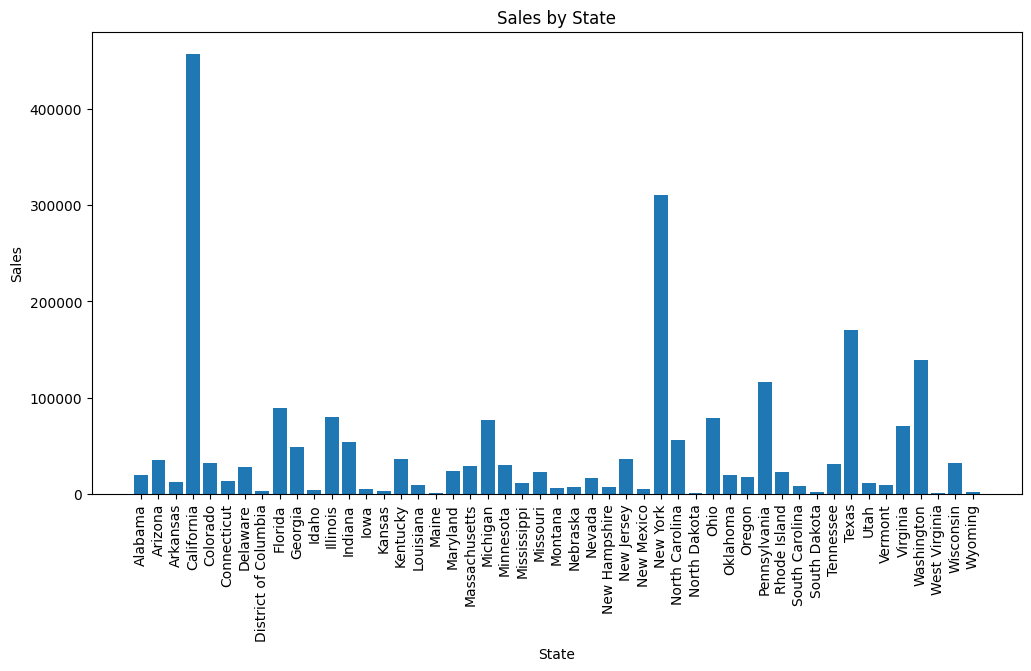

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.bar(state_sales.index, state_sales.values)
plt.xlabel("State")
plt.ylabel("Sales")
plt.title("Sales by State")
plt.xticks(rotation=90)
plt.show()


In [16]:
#What is the difference between New York and California in terms of sales and profit? (Compare the total sales and profit between New York and California.)
ny_ca = df[df["State"].isin(["New York", "California"])]
ny_ca.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,0.0,6.8714
5,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,0.0,14.1694
6,7,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.280,4,0.0,1.9656
7,8,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.152,6,0.2,90.7152
8,9,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.504,3,0.2,5.7825


In [18]:
comparison = ny_ca.groupby("State")[["Sales", "Profit"]].sum()
comparison

,Sales,Profit
State,,
California,457687.6315,76381.3871
New York,310876.2710,74038.5486


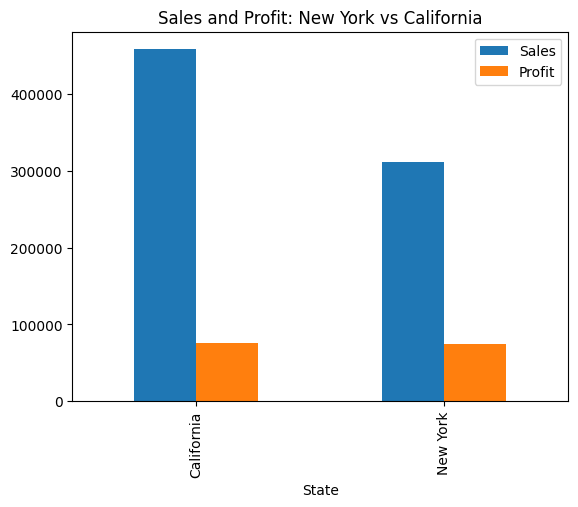

In [20]:
comparison.plot(kind="bar")
plt.title("Sales and Profit: New York vs California")
plt.show()

In [28]:
#Who is an outstanding customer in New York?
ny_data = df[df["State"] == "New York"]
customer_sales = ny_data.groupby("Customer Name")["Sales"].sum()
customer_sales = customer_sales.sort_values(ascending=False)
customer_sales.head()


,Sales
Customer Name,
Tom Ashbrook,13723.498
Peter Fuller,7678.228
Seth Vernon,7359.918
Tom Boeckenhauer,6999.960
Greg Tran,6712.744


In [30]:
top_customer = customer_sales.head(1)
top_customer

,Sales
Customer Name,
Tom Ashbrook,13723.498


In [32]:
top10 = customer_sales.head(10)

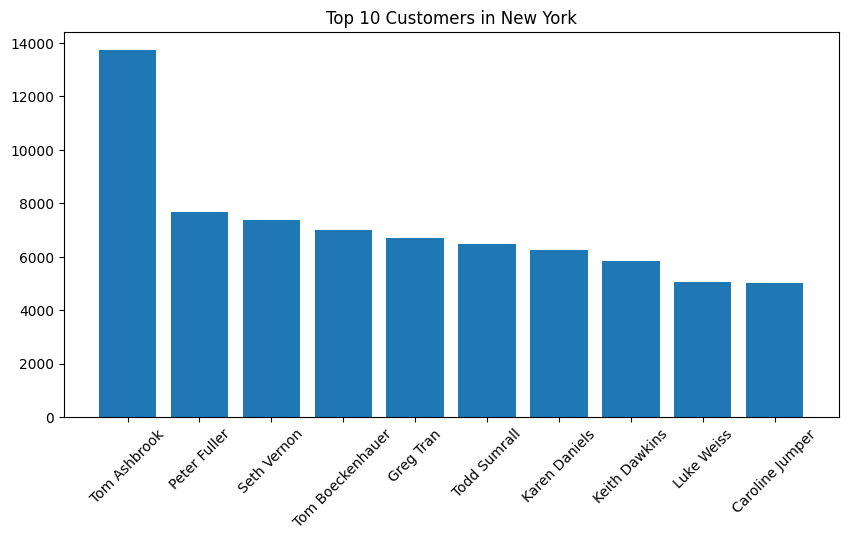

In [33]:
plt.figure(figsize=(10,5))

plt.bar(top10.index, top10.values)

plt.xticks(rotation=45)

plt.title("Top 10 Customers in New York")

plt.show()

In [35]:
#Are there any differences among states in profitability?
state_profit = df.groupby("State")["Profit"].sum()
state_profit = state_profit.sort_values()
state_profit.head()

,Profit
State,
Texas,-25729.3563
Ohio,-16971.3766
Pennsylvania,-15559.9603
Illinois,-12607.8870
North Carolina,-7490.9122


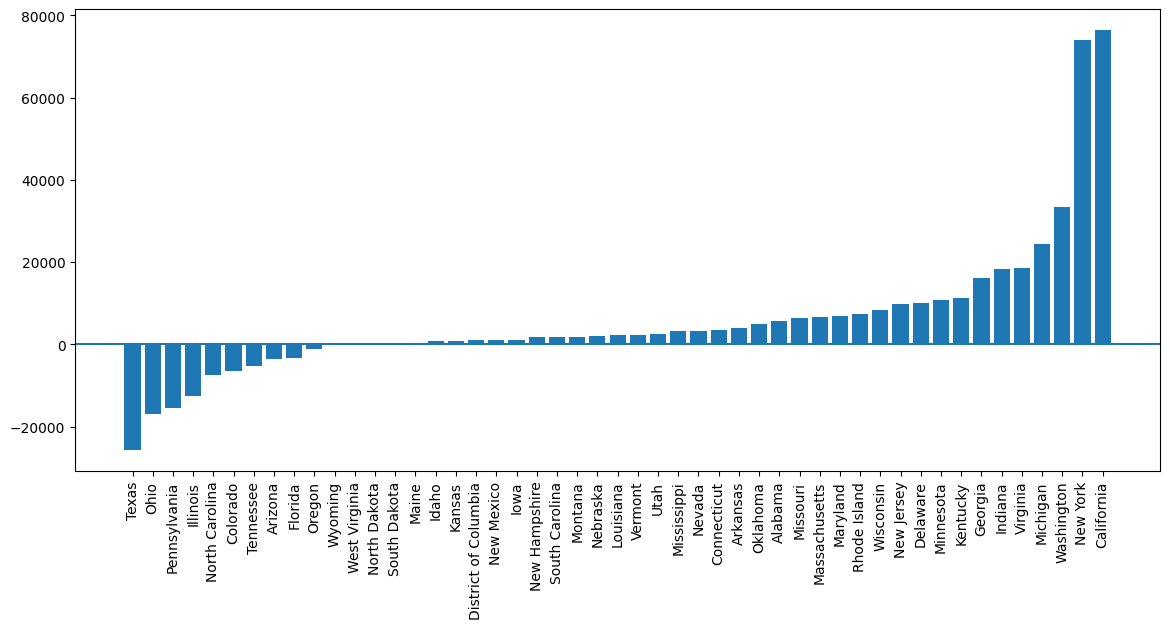

In [37]:
plt.figure(figsize=(14,6))
plt.bar(state_profit.index, state_profit.values)
plt.xticks(rotation=90)
plt.axhline(0) #линия нуля
plt.show()

In [41]:
#The Pareto Principle, also known as the 80/20 rule, is a concept derived from the work of Italian economist Vilfredo Pareto. It states that roughly 80% of the effects come from 20% of the causes. For instance, identifying the top 20% of products that generate 80% of sales or the top 20% of customers that contribute to 80% of profit can help in prioritizing efforts and resources. This focus can lead to improved efficiency and effectiveness in business strategies. Can we apply Pareto principle to customers and Profit ? (Determine if 20% of the customers contribute to 80% of the profit.)
#Проверяем: “Дают ли 20% клиентов примерно 80% прибыли?”
customer_profit = df.groupby("Customer Name")["Profit"].sum() #профит по клиентам
customer_profit = customer_profit.sort_values(ascending=False)
customer_profit

,Profit
Customer Name,
Tamara Chand,8981.3239
Raymond Buch,6976.0959
Sanjit Chand,5757.4119
Hunter Lopez,5622.4292
Adrian Barton,5444.8055
...,...
Henry Goldwyn,-2797.9635
Sharelle Roach,-3333.9144
Luke Foster,-3583.9770


In [43]:
cumulative_profit = customer_profit.cumsum()
total_profit = customer_profit.sum()

cumulative_percentage = cumulative_profit / total_profit * 100
customers_80 = cumulative_percentage[cumulative_percentage <= 80] #сколько клиентов дают 80% профита
num_top_customers = len(customers_80)
total_customers = len(customer_profit)
percentage_customers = num_top_customers / total_customers * 100
print("Percentage of customers contributing to 80% profit:")

print(percentage_customers)

Percentage of customers contributing to 80% profit:
19.167717528373267


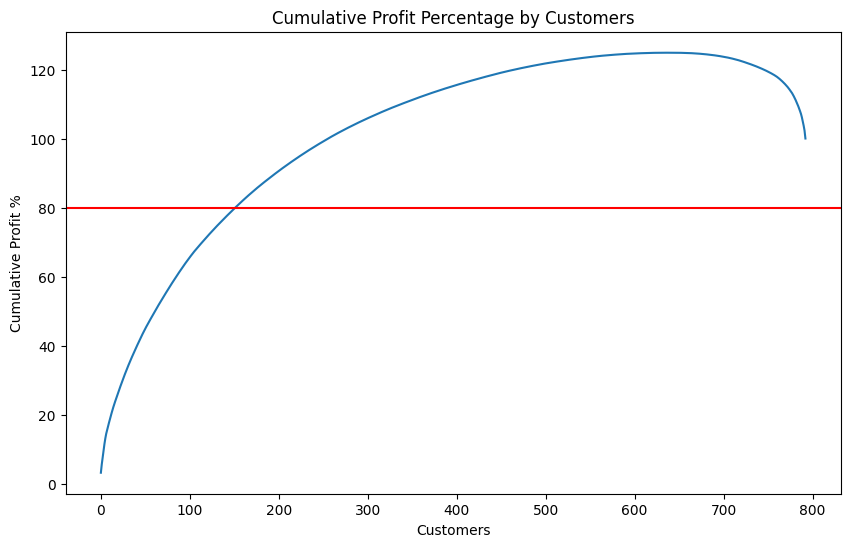

In [44]:
plt.figure(figsize=(10,6))

plt.plot(cumulative_percentage.values)

plt.axhline(80, color="red")

plt.title("Cumulative Profit Percentage by Customers")

plt.xlabel("Customers")

plt.ylabel("Cumulative Profit %")

plt.show()

In [45]:
#What are the Top 20 cities by Sales ? What about the Top 20 cities by Profit ? Are there any difference among cities in profitability ? (Identify the top 20 cities based on total sales and total profit and analyze differences in profitability among these cities.)
city_sales = df.groupby("City")["Sales"].sum()
city_sales = city_sales.sort_values(ascending=False)
top20_sales = city_sales.head(20)
top20_sales

,Sales
City,
New York City,256368.1610
Los Angeles,175851.3410
Seattle,119540.7420
San Francisco,112669.0920
Philadelphia,109077.0130
Houston,64504.7604
Chicago,48539.5410
San Diego,47521.0290
Jacksonville,44713.1830


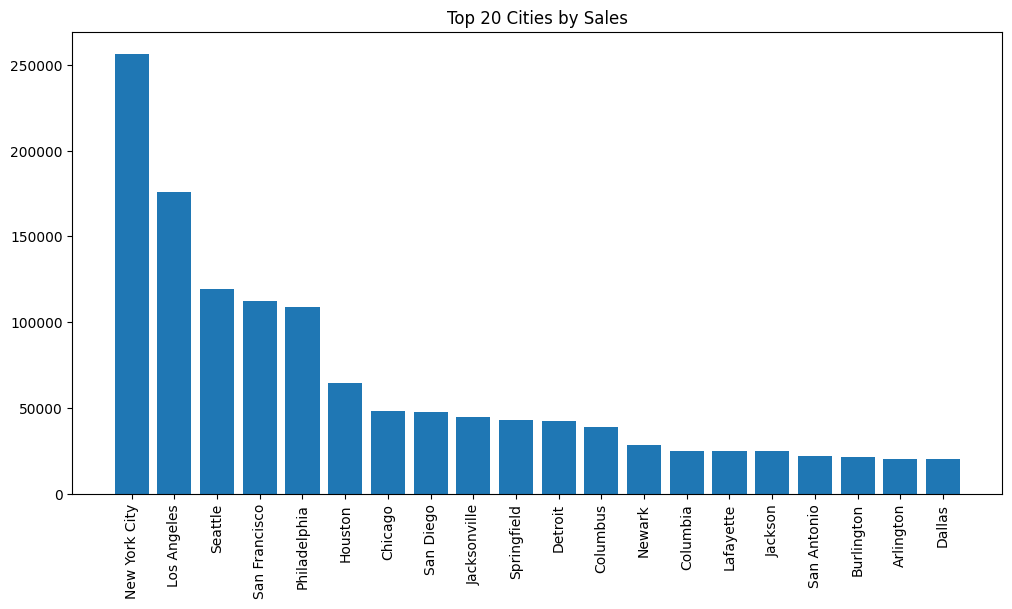

In [46]:
plt.figure(figsize=(12,6))

plt.bar(top20_sales.index, top20_sales.values)

plt.xticks(rotation=90)

plt.title("Top 20 Cities by Sales")

plt.show()

In [47]:
city_profit = df.groupby("City")["Profit"].sum()
city_profit = city_profit.sort_values(ascending=False)
top20_profit = city_profit.head(20)
top20_profit

,Profit
City,
New York City,62036.9837
Los Angeles,30440.7579
Seattle,29156.0967
San Francisco,17507.3854
Detroit,13181.7908
Lafayette,10018.3876
Jackson,7581.6828
Atlanta,6993.6629
Minneapolis,6824.5846


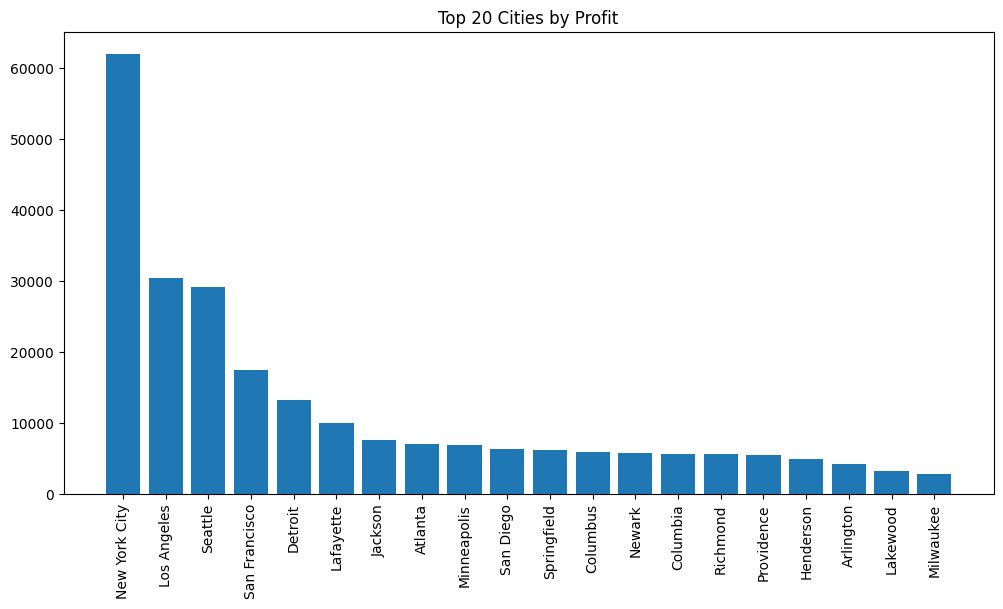

In [48]:
plt.figure(figsize=(12,6))

plt.bar(top20_profit.index, top20_profit.values)

plt.xticks(rotation=90)

plt.title("Top 20 Cities by Profit")

plt.show()

In [49]:
city_summary = df.groupby("City")[["Sales", "Profit"]].sum()
city_summary["Profit Ratio"] = city_summary["Profit"] / city_summary["Sales"]
city_summary = city_summary.sort_values(
    by="Profit Ratio",
    ascending=False
)
city_summary.head(10)

,Sales,Profit,Profit Ratio
City,,,
Atlantic City,23.36,11.6800,0.500000
Grand Island,15.96,7.9800,0.500000
New Brunswick,14.77,7.1567,0.484543
Summerville,406.94,196.9132,0.483888
Holland,137.86,66.6588,0.483525
Antioch,19.44,9.3312,0.480000
Davis,32.40,15.5520,0.480000
Royal Oak,35.34,16.9632,0.480000
Lindenhurst,55.48,26.6304,0.480000


In [50]:
city_summary.tail(10)

,Sales,Profit,Profit Ratio
City,,,
Waco,606.1072,-520.1034,-0.858105
Champaign,151.9600,-182.3520,-1.200000
Tyler,347.2060,-443.7086,-1.277940
Littleton,72.2940,-98.8018,-1.366667
Deer Park,6.9240,-10.3860,-1.500000
Missouri City,6.3700,-9.5550,-1.500000
Romeoville,8.9520,-14.7708,-1.650000
Oswego,321.9780,-536.1276,-1.665106
Mesquite,52.1480,-87.6200,-1.680218


In [57]:
#What are the Top 20 customers by Sales?
customer_sales = df.groupby("Customer Name")["Sales"].sum()

customer_sales = customer_sales.sort_values(ascending=False)

top20_customers = customer_sales.head(20)


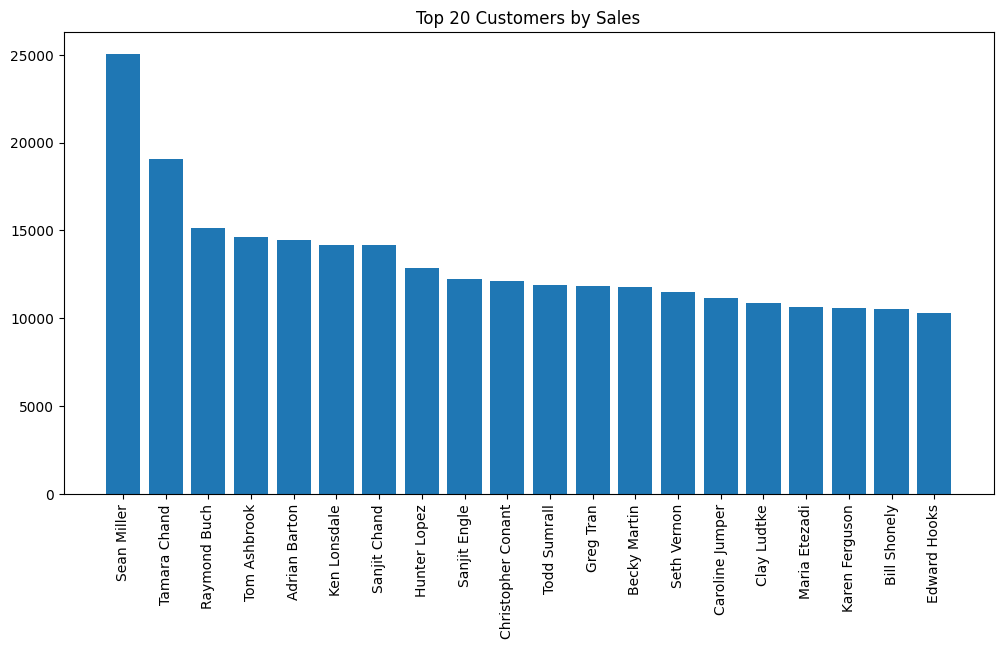

In [58]:
plt.figure(figsize=(12,6))

plt.bar(top20_customers.index, top20_customers.values)

plt.xticks(rotation=90)


plt.title("Top 20 Customers by Sales")
plt.show()

In [60]:
#Plot the Cumulative curve in Sales by Customers. Can we apply Pareto principle to customers and Sales ?
cumulative_sales = customer_sales.cumsum()
total_sales = customer_sales.sum()
cumulative_sales_percentage = cumulative_sales / total_sales * 100
#customers_80 = cumulative_sales_percentage[cumulative_sales_percentage <= 80]

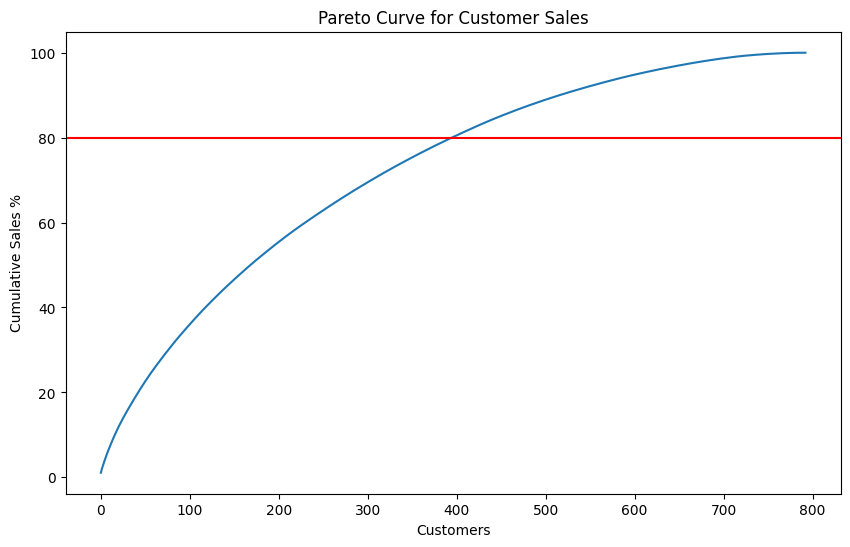

In [62]:
plt.figure(figsize=(10,6))
plt.plot(cumulative_sales_percentage.values)
plt.axhline(80, color="red")
plt.xlabel("Customers")
plt.ylabel("Cumulative Sales %")
plt.title("Pareto Curve for Customer Sales")
plt.show()

In [63]:
customers_80_sales = cumulative_sales_percentage[
    cumulative_sales_percentage <= 80
]
num_customers_80 = len(customers_80_sales)
total_customers = len(customer_sales)
percentage_customers_sales = (
    num_customers_80 / total_customers * 100
)
print(percentage_customers_sales)

49.810844892812106


The Pareto Principle does not strongly apply to customer sales in this dataset, since around 49% of customers contribute to 80% of total sales. This suggests that sales are relatively distributed across a broader customer base rather than concentrated among a small group of customers.

Based on the analysis, make decisions on which states and cities to prioritize for marketing strategies.
Marketing Strategy Recommendations
States to Prioritize
California
California has the highest sales and strong overall profit.
It represents a large and profitable market.
Marketing investments here are likely to generate strong returns.
New York
New York also shows high sales and high profitability.
The state contains valuable customers and strong business potential.
Retention campaigns and premium customer programs could be effective.
States Requiring Attention
States with high sales but low profit
Some states generate strong sales but weak profitability.
This may indicate:
excessive discounts
high operational costs
inefficient logistics
Recommendation
Optimize pricing and discount strategies.
Improve operational efficiency before increasing marketing spend.
Cities to Prioritize
Top cities by Sales and Profit
Cities appearing in both Top Sales and Top Profit lists should receive priority marketing investment.
These cities already demonstrate:
strong demand
healthy profitability
high customer value
Cities with high sales but low profitability
These cities should be analyzed carefully before expanding marketing budgets.
Focus should be placed on improving margins rather than only increasing sales volume.
Customer Strategy
The Pareto analysis showed that profit is concentrated among a smaller group of customers.
High-profit customers should receive:
loyalty programs
personalized offers
retention campaigns
Sales are more broadly distributed across customers, meaning the company also benefits from maintaining a wide customer base.
Final Recommendation

The company should prioritize:

High-sales and high-profit states such as California and New York.
Cities that perform strongly in both sales and profitability.
Retention and upselling strategies for high-profit customers.
Profit optimization in regions with strong sales but weak margins.
